# Quantum State Prep - Part 3 
**QRE Analysis**

In the previous tutorial we implemented the function `prep_multiqubit` (reproduced below) to generate a multi-qubit state preparation circuit. 

We now ask the question: what resources would we need to run this circuit on fault-tolerant hardware? This is question of _quantum resource estimation_. Essentially, we want an accurate estimate of the quantum resources needed to run an algorithm fault-tolerantly. 

In this tutorial, we will show how PsiQDK helps you answer this question.

## 1. Quantum Resource Estimation in Workbench

There are many different answers to this question that can depend not only on the resource of interest, but also what assumptions you make on circuit compilation. We are restricted in the operations we can access at the logical level, and so certain gates must be compiled into our logical gate set. We will assume we have access to the Clifford+$T$ gate set.

When designing Workbench, we chose a set of metrics that are particularly relevant for interpreting fault-tolerant algorithm runtime and complexity, without making too many assumptions on compilation techniques. 
These are:
- **T gates**: The most common metric for evaluating complexity of a quantum algorithm.
- **Toffoli gates**: Toffoli gates can be decomposed into a sequence of $T$-gates and Clifford gates, but they can be easier to interpret algorithmically.
- **Rotations**: Arbitrary rotations must be synthesized into $T$-gates and Cliffords for implementation. Due to the large variability in synthesis methods, if an algorithm requires many rotations it may indicate the need for a more careful approach rather than applying one synthesis method globally. 
- **Measurements**: Some measurements require feedback loops between the classical control unit and the QPU, which can create a bottleneck.
- **Active volume**: Introduced in "Active volume: An architecture for efficient fault-tolerant quantum computers with limited non-local connections" ([arXiv:2211.15465](https://arxiv.org/abs/2211.15465)), the active volume is a metric for measuring the time and space complexity of quantum algorithms. Roughly speaking, it can be understood as the total cost of all logical operations in the algorithm. This is an alternative metric to quantum volume, defined as the number of qubits multiplied by the number of $T$-gate layers.

A more complete discussion of QREs in Workbench can be found in the [documentation](https://construct.psiquantum.com/docs/psiqdk-workbench/new-tutorials/Resource-Estimates-Basic-Numerics.html).

In [ ]:
%%capture
%pip install psiqdk
%pip install typing_extensions
%pip install numpy
%pip install matplotlib
%pip install pytest
%pip install scipy

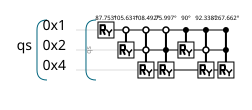

In [ ]:
from math import atan2, sqrt
from psiqdk.workbench import QPU, Qubits, units


def prep_multiqubit(qs: Qubits, amps: list[float], cond: int | list[int] | None = None):
    "Prepare multi-qubit state with the given amplitudes"

    if qs.num_qubits == 1:
        theta = 2 * atan2(amps[1], amps[0])
        qs.ry(theta * units.rad, cond=cond)
    else:
        # Prepare the least significant qubit (LSB)
        even_amps = amps[0::2]
        odd_amps = amps[1::2]
        b0 = sqrt(sum(a * a for a in even_amps))
        b1 = sqrt(sum(a * a for a in odd_amps))

        # Make sure to pass the control register as an argument
        # to allow the entire routine to be controlled.
        prep_multiqubit(qs[0], [b0, b1], cond)

        # Prepare the most significant n-1 bits, controlled on LSB=0
        prep_multiqubit(qs[1:], even_amps, cond | (qs[0] == 0))

        # Prepare the most significant n-1 bits, controlled on LSB=1
        prep_multiqubit(qs[1:], odd_amps, cond | qs[0])


qpu = QPU(num_qubits=3)
qs = Qubits(3, "qs", qpu)
prep_multiqubit(qs, [0.36, 0.48, 0.64, -0.48, -0.5, 0.5, 0.5, -0.5])
qpu.draw()

This circuit contains arbitrary rotations around the $Y$-axis, $Ry$, as well as single- and multi-controlled rotations.
To get a more accurate picture of what this circuit would look like after some gate compilation, we can pass in filters to our QPU. 
These tell the QPU how we want to compile the operations in our circuit.

For our circuit we want to get rid of controlled $Ry$ gates, and we employ two filters:
- `clean-ladder-filter` : Decomposes multi-controlled gates into single-controlled gates and left/right "Gidney elbows", also known as _unary iterations_ from "Encoding Electronic Spectra in Quantum Circuits with Linear T Complexity" ([arXiv:1805.03662](https://arxiv.org/abs/1805.03662)).
- `single-control-filter` : Decomposes single-controlled gates into controlled Paulis and single-qubit gates.

The `>>` syntax ensures that the input to the filter is accepted from the upstream, and the output from the filter is passed downstream. The `buffer` filter allows us to draw circuits; in previous examples there was no need for us to provide this filter explicitly, as it is one of the default filters. A complete breakdown of the passable filters in Workbench can be seen in the [documentation](https://construct.psiquantum.com/docs/psiqdk-workbench/new-tutorials/Configuring-Execution.html).

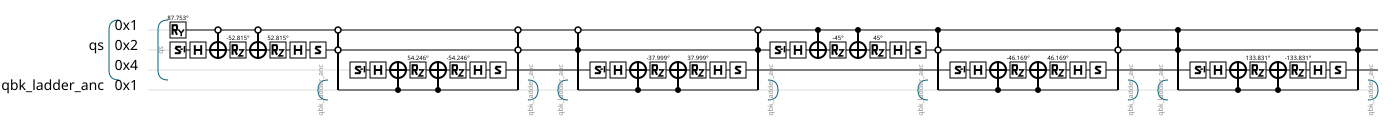

In [2]:
qpu = QPU(
    filters=[">>clean-ladder-filter>>", ">>single-control-filter>>", ">>buffer>>"],
    num_qubits=4     # We needed one extra qubit for decomposing our multi-controlled gates!
)
qs = Qubits(3, "qs", qpu)
prep_multiqubit(qs, [0.36, 0.48, 0.64, -0.48, -0.5, 0.5, 0.5, -0.5])
qpu.draw()

<div class="alert alert-block alert-info">
<b>Note:</b> Order matters! <b>clean-ladder-filter</b> decomposes multi-controlled gates into single controlled gates, and <b>single-control-filter</b> decomposes single controlled gates. If we reversed the order of these filters we would be left with some single controlled gates!
</div>

Multi-controlled gates require auxiliary qubits in order to be decomposed: gates with two controls require one auxiliary, three controls requires two, etc. As such, we needed to specify that we'd use one extra qubit on our QPU object. In the diagram it is labelled `qbk_ladder_anc`.
If we had not specified this extra qubit, the QPU would have thrown an error!

You can see our circuit has gotten significantly more complex, although it is now broken down into multiple Clifford operations, single-qubit rotations, and Gidney elbows. 

To get a snapshot of the resource cost of this circuit, we can create a `ResourceEstimator` object, passing it the QPU as the argument, and call its `resources()` method.

In [3]:
from psiqdk.workbench.qre import resource_estimator
resource_estimator(qpu).resources()

{'active_volume': 10009.0,
 'gidney_lelbows': 4,
 'gidney_relbows': 4,
 'measurements': 0,
 'rotations': 11,
 'pprs': 0,
 'ppms': 0,
 't_gates': 2,
 'toffs': 0,
 'qubit_highwater': 4}

Let's go through this metric breakdown:
- **qubit_highwater=4** : This one's easy - there are four logical qubits.
- **t_gates=2** : We didn't define any $T$ gates in our circuit, but our input amplitudes and subsequent decomposition resulted in two $Rz$ gates with rotation angles $\pm45^\circ$ - which are $T$ gates.
- **gidney_lelbows=gidney_relbows=4** : Each of the four double-controlled $Ry$ gate was decomposed into a sequence of one- and two-qubit gates, bracketed by left and right Gidney elbows.
- **rotations=11** : There are $12$ $Rz$ gates and $1$ $Ry$ gate in the circuit, but two of these $Rz$ gates are already counted in **t_gates**.
- **active_volume=10009** : Total AV cost of the circuit; a description of this concept can be found in "Active volume: An architecture for efficient fault-tolerant quantum computers with limited non-local connections" ([arXiv221.15465](https://arxiv.org/abs/2211.15465)).

We now briefly introduce the workhorse behind these metrics in Workbench: the `WitnessCounter`. The `WitnessCounter` tracks (and counts!) the individual operations in a quantum program, and `resource_estimator()` is just an interface to a summary of the information.

If we print the `QPU.witness` property, we will see a nicely formatted list of all the quantum operations being counted, plus some extra information such as the numbers of one- and two-qubit Clifford gates.

In [4]:
print(qpu.witness)

TOTAL METRICS SUMMARY:
----------------------
rotations:           11
t_gates:             2
measurements:        0
gidney_lelbows:      4
gidney_relbows:      4
toffs:               0
pprs:                0
ppr_av:              0
ppms:                0
ppm_av:              0
single_qubit_cliffords:24
two_qubit_cliffords: 12
active_volume:       10009.0
black_box_av:        0
single_qubit_clifford_av:96
two_qubit_clifford_av:48
uncontrolled_non_clifford_av:9669.0
singly_controlled_non_clifford_av:0
two_controlled_non_clifford_av:196

WITNESS BREAKDOWN:
------------------
QPU ops:
--------
OP: (name = qc.had, target = 1, condition = 0, theta = 0, reactive = 0, error_param = 0)
COUNT: 12
METRICS:
    single_qubit_cliffords: cost per op: 1       total cost: 12
    active_volume:  cost per op: 3       total cost: 36
    single_qubit_clifford_av: cost per op: 3       total cost: 36

OP: (name = qc.lelbow, target = 1, condition = 2, reactive = 0)
COUNT: 4
METRICS:
    gidney_lelbows: cost pe

There are some quantum operations listed in `Qubrick ops` and `Other ops` in the witness that don't show up in the `ResourceEstimator` output. Qubit reset, allocation and deallocation are all counted as quantum operations. "Qubricks" are our terminology for units of quantum computation at any level of abstraction above individual qubit gates, and these will be explored in a later tutorial. By design these Qubrick objects have `compute` and `uncompute` commands, and these are also counted as operations.

The `WitnessCounter` object can be considered an alternative representation of quantum algorithms in Workbench &mdash; time-agnostic lists of unique operations and the number of their occurrences, categorized into the primitives of Workbench.

The final metric to address is **active_volume=10009**. Active volume is a more advanced metric which depends on certain assumptions about the architecture of a quantum computer being used. Explaining it is beyond the scope of this tutorial; you can find more details in "Active volume: An architecture for efficient fault-tolerant quantum computers with limited non-local connections" ([arXiv221.15465](https://arxiv.org/abs/2211.15465)).

## 2. Analyzing the performance of our algorithm

We now ask: how good is our recursive state preparation algorithm? In this section we will explore the metrics of our algorithm as we change the number of qubits in the target state. We won't worry about the specific amplitudes, as the metrics are the same for a fixed number of qubits. We will then want to compare our algorithm to something more state-of-the-art.

Alias Sampling, introduced in "Encoding Electronic Spectra in Quantum Circuits with Linear T Complexity" ([arXiv:1805.03662](https://arxiv.org/abs/1805.03662)), is a method for arbitrary state preparation, and has been integrated into Workbench Algorithms. A more pedagogical introduction to this method can be found in the "Preparing Superpositions" section of this post on [Craig Gidney's blog](https://algassert.com/post/1805). 

We'll employ the prebuilt Alias Sampling algorithm to compare to our recursive state preparation.

First, we'll define a function to quickly return the number of Toffoli gates required for recursive state preparation on an arbitrary number of qubits.

> Note that in this algorithm the raw count of Toffoli gates is always 0, but, as shown in Fig. 4 in "Encoding Electronic Spectra in Quantum Circuits with Linear T Complexity" ([arXiv:1805.03662](https://arxiv.org/abs/1805.03662)), _left_ Gidney elbows are equivalent to Toffoli gates. We use the sum of these two numbers in the plots in this tutorial.

In [5]:
import numpy as np


def recursive_state_prep_toffolis(num_qubits: int) -> int:
    """Get the number of Toffoli gates required for recursive state preparation on an arbitrary number of qubits.

    Args:
        num_qubits: The number of qubits in our target state.

    Returns:
        int: The number of Toffoli gates
    """
    qpu = QPU(
        filters=[">>clean-ladder-filter>>", ">>single-control-filter>>", ">>buffer>>"],
        num_qubits=2 * num_qubits - 2    # In general we require n-2 more qubits for decomposition.
    )
    qs = Qubits(num_qubits, "qs", qpu)
    amps = np.random.sample(2 ** num_qubits)  # Randomly generate some amplitudes.
    prep_multiqubit(qs, amps)
    resources = resource_estimator(qpu).resources()
    return resources["toffs"] + resources["gidney_lelbows"]

Below, we plot the Toffoli gate count metric as a function of the number of qubits in our target state. As a point of reference, we also plot the $2^n$ line, to give an idea of the (poor) scaling of our recursive state preparation algorithm!

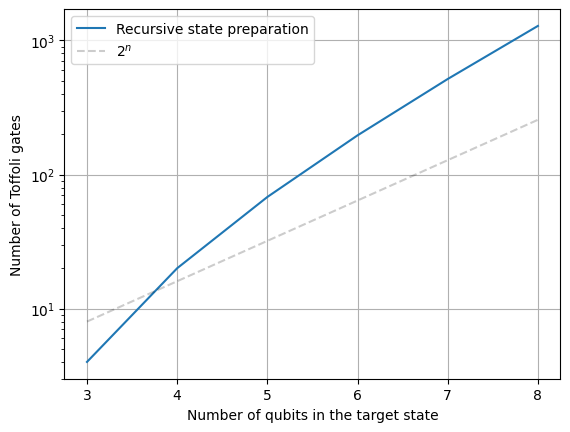

In [6]:
import matplotlib.pyplot as plt

qubits = np.asarray(range(3, 9))
plt.plot(
    qubits,
    [recursive_state_prep_toffolis(q) for q in qubits],
    label="Recursive state preparation",
)
plt.plot(
    qubits, 2 ** (qubits), label=r"$2^n$", alpha=0.2, color="black", linestyle="--"
)
plt.yscale("log")
plt.legend()
plt.xlabel("Number of qubits in the target state")
plt.ylabel("Number of Toffoli gates")
plt.grid(True)

Now, we import some objects from Workbench Algorithms to define our Alias Sampling routine. The details of the algorithm implementation are out of scope for this tutorial. We will discuss the usage of Workbench Algorithms subroutines in a later tutorial.

In [7]:
from psiqdk.algorithms import (
    AliasSampling,
    DataLookupClean,
    BinaryTreeSelect,
    SwapUp,
    USP,
)

qrom = DataLookupClean(select=BinaryTreeSelect(), swap_up=SwapUp())
uniform_state_preparation = USP()
alias = AliasSampling(qrom, uniform_state_preparation)

In [8]:
def alias_sampling_toffolis(num_qubits: int) -> int:
    """Get the number of Toffoli gates required for alias sampling given an arbitrary number of qubits.

    Args:
        num_qubits: The number of qubits in our target state.

    Returns:
        int: The number of Toffoli gates
    """
    # The required number of qubits for Alias Sampling follows a non-intuitive pattern;
    # 176 is the total required for preparing a 10-qubit state
    qpu = QPU(
        filters=[">>clean-ladder-filter>>", ">>single-control-filter>>", ">>buffer>>"],
        num_qubits=176
    )
    qs = Qubits(num_qubits, "qs", qpu)
    amps = np.random.sample(2 ** num_qubits)
    alias.compute(prep_reg=qs, input_list=amps, bit_precision=10)
    resources = resource_estimator(qpu).resources()
    return resources["toffs"] + resources["gidney_lelbows"]

The below code snippet will create lists of Toffoli gate counts of both alias sampling and recursive state preparation. The data on the other metrics is retrievable in the same way. 

In [9]:
alias_sampling: list[int] = []
recursive_state_prep: list[int] = []
for num_qubits in range(3, 9):
    alias_sampling.append(alias_sampling_toffolis(num_qubits))
    recursive_state_prep.append(recursive_state_prep_toffolis(num_qubits))

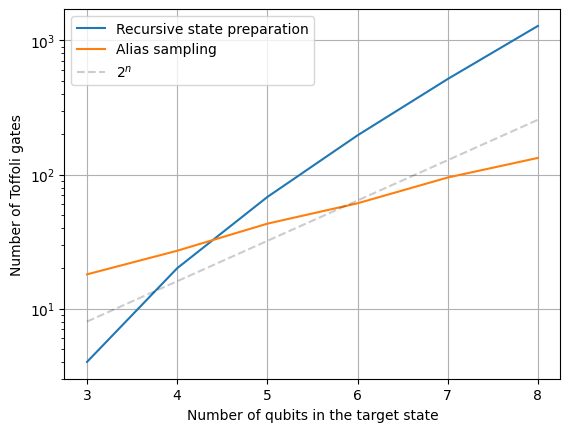

In [10]:
qubits = np.asarray(range(3, 9))
plt.plot(qubits, recursive_state_prep, label="Recursive state preparation")
plt.plot(qubits, alias_sampling, label="Alias sampling")
plt.plot(
    qubits, 2 ** (qubits), label=r"$2^n$", alpha=0.2, color="black", linestyle="--"
)
plt.yscale("log")
plt.xlabel("Number of qubits in the target state")
plt.ylabel("Number of Toffoli gates")
plt.legend()
plt.grid(True)

As you can see, aside from the smallest example, alias sampling will always exhibit better performance **with regards to Toffoli gate count** than our naive recursive state preparation algorithm.

A follow-up question would be: Where does alias sampling _underperform_ compared to our naive implementation? Is this a good tradeoff? Answering these kinds of questions, and optimizing our algorithms with that information, is at the heart of the design choices for Workbench and the rest of the PsiQuantum software suite. 

## Conclusion

In this tutorial we explored how to approach quantum resource estimation in Workbench, how to visualize that information in Resource Analyzer, and ran some simple simulations to compare our implementation with a ready-made, state-of-the-art algorithm. 

This is only scratching the surface of the problem of quantum resource estimation! In the [next tutorial](./satsolver_1_circuit.html) we will work with another PsiQuantum software package, [`Bartiq`](https://github.com/PsiQ/bartiq), which is specifically designed for algorithm QRE exploration.